In [ ]:
#importing modules 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

In [ ]:
# Load cleaned data
df = pd.read_csv('../data/cleaned_data.csv')


# Drop Destination Port and duplicate column if still present
cols_to_drop = ['Destination Port']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Split features and labels
X = df.drop(columns=['Label'])
y = df['Label']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = joblib.load('../models/scaler.pkl')
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data loaded and ready.")
print(f"Training: {X_train_scaled.shape}, Testing: {X_test_scaled.shape}")

Data loaded and ready.
Training: (180568, 77), Testing: (45143, 77)


In [9]:
from sklearn.ensemble import RandomForestClassifier
import time

# Initialise the model
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    random_state=42,     # for reproducibility
    n_jobs=-1            # use all CPU cores — speeds up training
)

# Train it and time how long it takes
start = time.time()
rf_model.fit(X_train_scaled, y_train)
end = time.time()

print(f"Training complete in {round(end - start, 2)} seconds.")

Training complete in 63.66 seconds.


In [10]:
from sklearn.ensemble import RandomForestClassifier
import time

# Initialise the model
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    random_state=42,     # for reproducibility
    n_jobs=-1            # use all CPU cores — speeds up training
)

# Train it and time how long it takes
start = time.time()
rf_model.fit(X_train_scaled, y_train)
end = time.time()

print(f"Training complete in {round(end - start, 2)} seconds.")

Training complete in 71.04 seconds.


Accuracy: 99.98%

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19538
        DDoS       1.00      1.00      1.00     25605

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



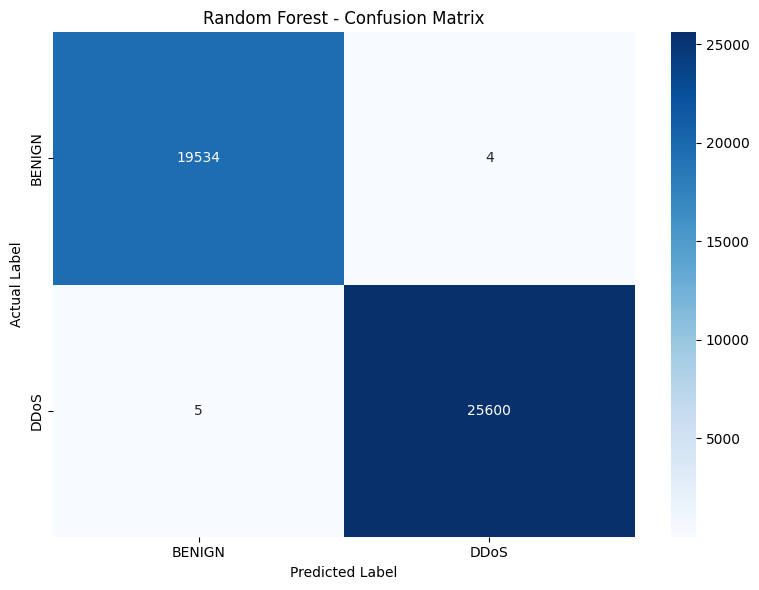

In [11]:
from sklearn.metrics import (classification_report, 
                              confusion_matrix, 
                              accuracy_score)
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = rf_model.predict(X_test_scaled)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {round(accuracy * 100, 2)}%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
                            target_names=['BENIGN', 'DDoS']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BENIGN', 'DDoS'],
            yticklabels=['BENIGN', 'DDoS'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png')
plt.show()

In [12]:
joblib.dump(rf_model, '../models/random_forest_model.pkl')
print("Model saved to models/random_forest_model.pkl")

Model saved to models/random_forest_model.pkl


Isolation Forest - Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.25      0.29      0.27     19538
        DDoS       0.39      0.34      0.36     25605

    accuracy                           0.32     45143
   macro avg       0.32      0.32      0.32     45143
weighted avg       0.33      0.32      0.32     45143



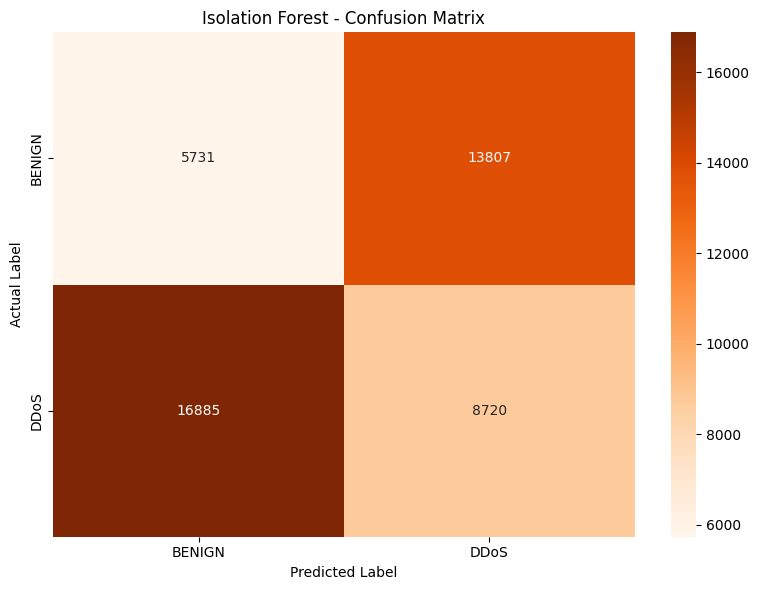

In [13]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Isolation Forest is unsupervised - trained on ALL data, no labels
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.5,   # maximum allowed by sklearn; true proportion is 0.57
    random_state=42,
    n_jobs=-1
)

# Train on scaled training features only (no labels)
iso_forest.fit(X_train_scaled)

# Predict on test set
# Isolation Forest returns: 1 = normal, -1 = anomaly
iso_pred_raw = iso_forest.predict(X_test_scaled)

# Convert to match our encoding: 0 = BENIGN, 1 = DDoS
iso_pred = [1 if x == -1 else 0 for x in iso_pred_raw]

# Evaluate
print("Isolation Forest - Classification Report:")
print(classification_report(y_test, iso_pred, 
                            target_names=['BENIGN', 'DDoS']))

# Confusion matrix
cm_iso = confusion_matrix(y_test, iso_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['BENIGN', 'DDoS'],
            yticklabels=['BENIGN', 'DDoS'])
plt.title('Isolation Forest - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('iso_confusion_matrix.png')
plt.show()

In [14]:
import joblib
joblib.dump(iso_forest, '../models/isolation_forest_model.pkl')
print("Isolation Forest model saved.")

Isolation Forest model saved.
